Part 1

In [256]:
import yfinance as yf
import numpy as np
import datetime
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from time import time
import matplotlib.pyplot as plt

In [257]:
start = datetime.datetime(2023, 11, 1)
end = datetime.datetime(2024, 11, 1)


onehour_step = 1
fourhour_step = 4
oneday_step = 24


coins = ("BTC-USD", "ETH-USD", "USDT-USD", "SOL-USD", "XRP-USD")

In [258]:
onehour_dict = {}
fourhour_dict = {}
oneday_dict = {}

for coin in coins:
    onehour_dict[coin] = (
        yf.Ticker(coin).history(interval="1h", start=start, end=end).Close
    )
    fourhour_dict[coin] = onehour_dict[coin][::fourhour_step]
    oneday_dict[coin] = (
        yf.Ticker(coin).history(interval="1d", start=start, end=end).Close
    )

In [259]:
onehour_dataframe = pd.DataFrame(onehour_dict).dropna()
fourhour_dataframe = pd.DataFrame(fourhour_dict)
oneday_dataframe = pd.DataFrame(oneday_dict)

In [260]:
stats = {}

In [261]:
for coin in onehour_dataframe.columns:
    print(f"{coin} Stationary Probability : {(1 - adfuller(oneday_dataframe[coin])[1])*100:.2f}")

BTC-USD Stationary Probability : 61.14
ETH-USD Stationary Probability : 73.21
USDT-USD Stationary Probability : 100.00
SOL-USD Stationary Probability : 82.03
XRP-USD Stationary Probability : 98.38


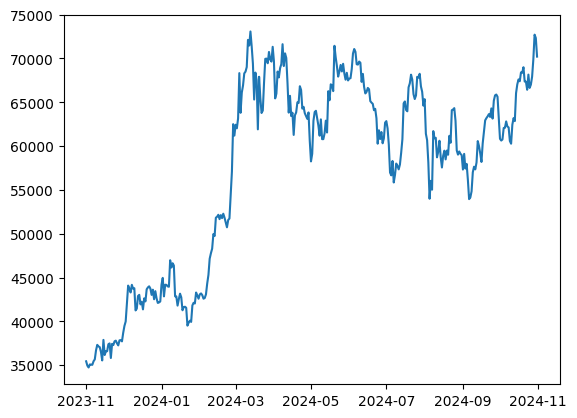

In [262]:
plt.plot(oneday_dataframe['BTC-USD'])

As we discovered, BTC-USD is non-stationary.

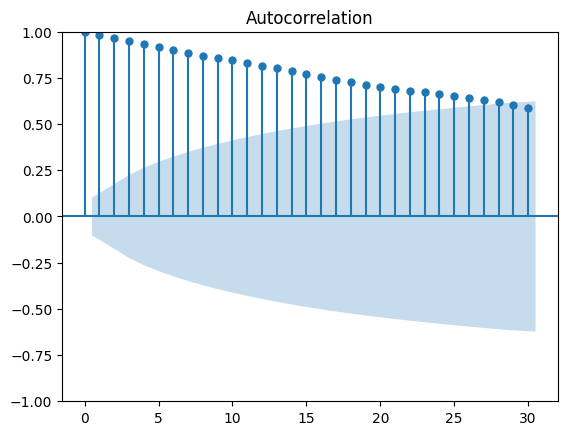

In [263]:
plot_acf(oneday_dataframe['BTC-USD'], lags=30)
plt.show()

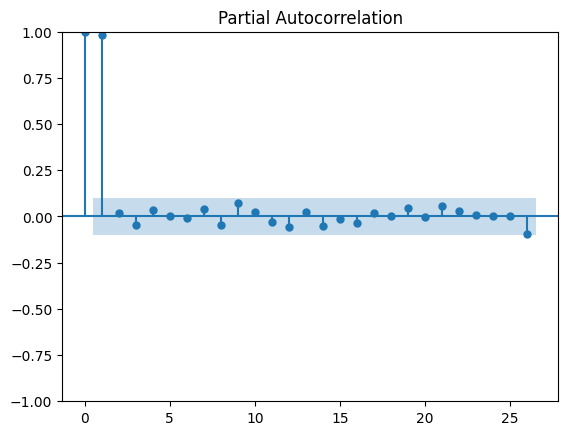

In [264]:
plot_pacf(oneday_dataframe['BTC-USD'], method="ywm")
plt.show()

In [265]:
oneday_dataframe.head(5)

,BTC-USD,ETH-USD,USDT-USD,SOL-USD,XRP-USD
Date,,,,,
2023-11-01 00:00:00+00:00,35437.253906,1847.089722,1.000611,41.461544,0.609538
2023-11-02 00:00:00+00:00,34938.242188,1800.620972,1.000213,40.207569,0.606439
2023-11-03 00:00:00+00:00,34732.324219,1832.795166,1.000650,39.519760,0.613002
2023-11-04 00:00:00+00:00,35082.195312,1857.698608,1.000781,42.346596,0.616184
2023-11-05 00:00:00+00:00,35049.355469,1894.157715,1.000724,41.238602,0.661147


In [266]:
train_start_time = datetime.datetime(2023, 11, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")
train_end_date = datetime.datetime(2024, 10, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")
test_start_date = datetime.datetime(2024, 10, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")
test_end_date = datetime.datetime(2024, 11, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")

train_data = oneday_dataframe["BTC-USD"][train_start_time:train_end_date]
test_data = oneday_dataframe["BTC-USD"][test_start_date:test_end_date]
train_data.index.freq = train_data.index.inferred_freq

In [267]:
model = ARIMA(pd.DataFrame(train_data), order=(25, 0, 25))

In [268]:
# fit the model
start = time()
model_fit = model.fit()
end = time()
print("Model fitting time is: ", end - start)

c:\Users\Win\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Win\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Win\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model fitting time is:  54.64629006385803


In [269]:
# summary of the model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                  336
Model:               ARIMA(25, 0, 25)   Log Likelihood               -2933.988
Date:                Thu, 12 Dec 2024   AIC                           5971.976
Time:                        23:53:51   BIC                           6170.465
Sample:                    11-01-2023   HQIC                          6051.099
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.638e+04   7682.722      7.339      0.000    4.13e+04    7.14e+04
ar.L1         -0.2918      1.908     -0.153      0.878      -4.032       3.448
ar.L2         -0.1874      1.209     -0.155      0.8

In [270]:
predictions = model_fit.predict(start=test_start_date, end=test_end_date)

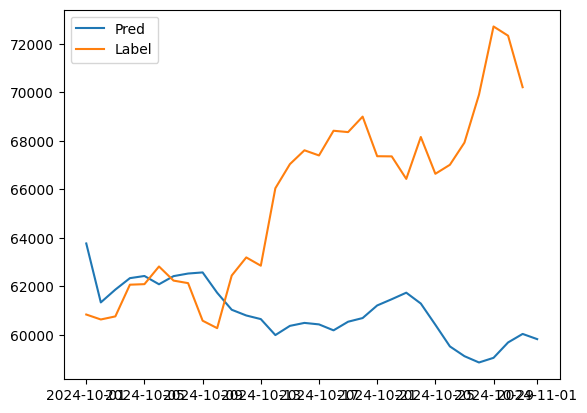

In [271]:
plt.plot(predictions, label="Pred")
plt.plot(test_data, label="Label")
plt.legend()

In [272]:
square = ((predictions - test_data) ** 2).dropna()
mse = square.sum() / len(square)

absolute_percentage = abs((predictions - test_data) / test_data)
mape = absolute_percentage.sum() / len(absolute_percentage)
print(f"MSE : {mse:.5f}, MAPE : {mape:.5f}")

MSE : 41793764.54203, MAPE : 0.07400


In [273]:
avg, dev = oneday_dataframe["BTC-USD"].mean(), oneday_dataframe["BTC-USD"].std()
normalized_data = (oneday_dataframe["BTC-USD"] - avg) / dev

In [274]:
first_diff_data = normalized_data.diff().dropna()

In [275]:
monthly_volatility = first_diff_data.groupby(first_diff_data.index.month).std()

In [276]:
monthly_volatility = first_diff_data.index.map(lambda d : monthly_volatility.loc[d.month])

In [277]:
non_volatility_data = first_diff_data / monthly_volatility

<Axes: xlabel='Date'>

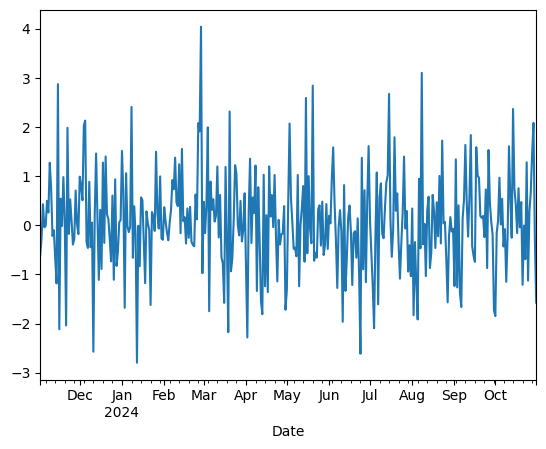

In [278]:
non_volatility_data.plot()

In [279]:
adfuller(non_volatility_data.dropna())

(-20.05367169911484,
 0.0,
 0,
 364,
 {'1%': -3.4484434475193777,
  '5%': -2.869513170510808,
  '10%': -2.571017574266393},
 985.4175426564759)

In [280]:
train_start_time = datetime.datetime(2023, 11, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")
train_end_date = datetime.datetime(2024, 10, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")
test_start_date = datetime.datetime(2024, 10, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")
test_end_date = datetime.datetime(2024, 11, 1).strftime("%Y-%m-%d %H:%M:%S+00:00")

train_data = non_volatility_data[train_start_time:train_end_date]
test_data = non_volatility_data[test_start_date:test_end_date]
train_data.index.freq = train_data.index.inferred_freq

In [281]:
model = ARIMA(pd.DataFrame(train_data).dropna(), order=(25, 0, 25))

In [282]:
# fit the model
start = time()
model_fit = model.fit()
end = time()
print("Model fitting time is: ", end - start)

c:\Users\Win\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Win\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Win\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model fitting time is:  65.38605880737305


In [283]:
# summary of the model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                  335
Model:               ARIMA(25, 0, 25)   Log Likelihood                -452.177
Date:                Thu, 12 Dec 2024   AIC                           1008.354
Time:                        23:54:58   BIC                           1206.689
Sample:                    11-02-2023   HQIC                          1087.425
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0526      0.049      1.077      0.282      -0.043       0.148
ar.L1         -0.2945      1.224     -0.241      0.810      -2.694       2.105
ar.L2          0.0970      1.127      0.086      0.9

In [284]:
predictions = model_fit.predict(start=test_start_date, end=test_end_date)

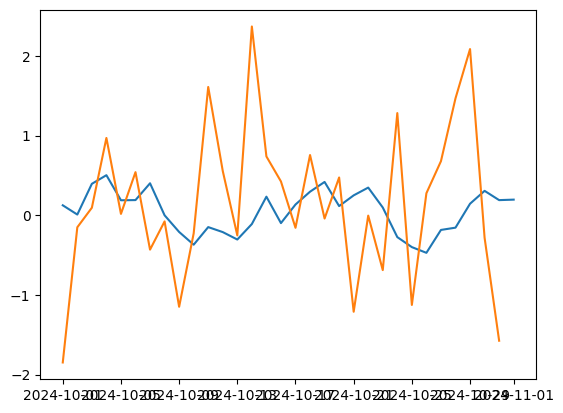

In [285]:
plt.plot(predictions, label="Preds")
plt.plot(test_data, label="Label")
plt.show()

In [286]:
squared = (predictions - test_data) ** 2
mse = squared.sum() / len(squared)

pct_changes = abs((predictions - test_data) / test_data)
mape = pct_changes.sum() / len(pct_changes)

In [287]:
mse, mape

(1.0622930395644379, 3.9987717008282075)

Part 2

In [288]:
coins = (
    "BTC-USD",
    "ETH-USD",
    "USDT-USD",
    "XRP-USD",
    "SOL-USD",
    "BNB-USD",
    "DOGE-USD",
    "USDC-USD",
    "ADA-USD",
    "TRX-USD",
)

start_date = datetime.datetime(2023, 11, 1)
end_date = datetime.datetime(2024, 11, 1)

In [289]:
oneday_dict = {}

for coin in coins:
    oneday_dict[coin] = yf.Ticker(coin).history(interval="1d", start=start_date, end=end_date).Close

oneday_dataframe = pd.DataFrame(oneday_dict).fillna(0)

<Axes: xlabel='Date'>

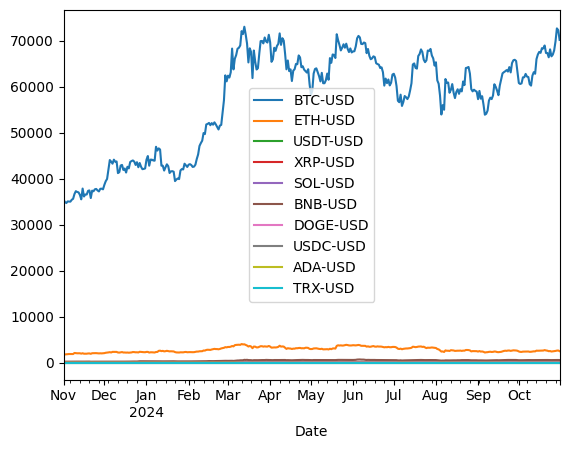

In [290]:
oneday_dataframe.plot()

<Axes: xlabel='Date'>

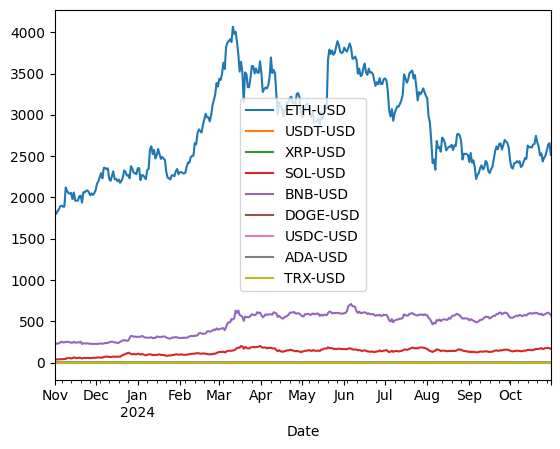

In [291]:
oneday_dataframe.drop("BTC-USD", axis=1).plot()

In [292]:
pct_changes = oneday_dataframe.pct_change().dropna()

<Axes: xlabel='Date'>

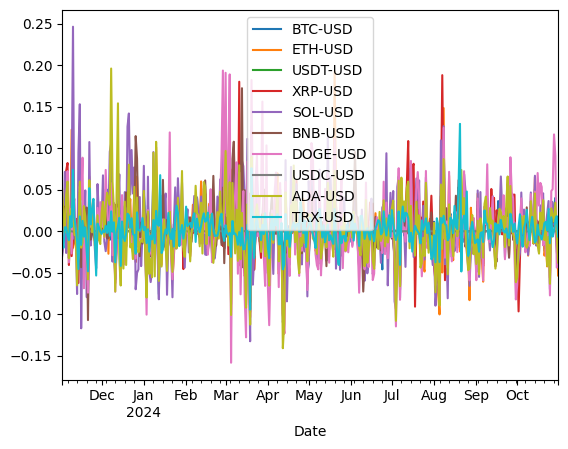

In [293]:
pct_changes.plot()

In [294]:
uptrend_change = pct_changes[pct_changes > 0].std()
downtrend_change = pct_changes[pct_changes < 0].std().abs()

In [295]:
changes = pd.DataFrame({"uptrend_change": uptrend_change, "downtrend_change": downtrend_change})

In [296]:
changes

,uptrend_change,downtrend_change
BTC-USD,0.020165,0.016955
ETH-USD,0.025207,0.020512
USDT-USD,0.000259,0.000238
XRP-USD,0.025770,0.022189
SOL-USD,0.035488,0.025732
BNB-USD,0.023851,0.018876
DOGE-USD,0.037181,0.028003
USDC-USD,0.000106,0.000093
ADA-USD,0.027024,0.023792
TRX-USD,0.014546,0.013218


همانظور که مشاهده می‌شود، میزان نوسانات به طور کلی در بازه‌های صعودی بیشتر از بازه‌های نزولی است. 

Part 4

In [297]:
from statsmodels.tsa.stattools import grangercausalitytests

In [298]:
coins = (
    "BTC-USD",
    "ETH-USD",
    "USDT-USD",
    "XRP-USD",
    "SOL-USD",
    "BNB-USD",
    "DOGE-USD",
    "USDC-USD",
    "ADA-USD",
    "TRX-USD",
)

start_date = datetime.datetime(2023, 11, 1)
end_date = datetime.datetime(2024, 11, 1)

In [299]:
oneday_dict = {}

for coin in coins:
    oneday_dict[coin] = yf.Ticker(coin).history(interval="1d", start=start_date, end=end_date).Close

In [300]:
oneday_dataframe = pd.DataFrame(oneday_dict).fillna(0)

<Axes: xlabel='Date'>

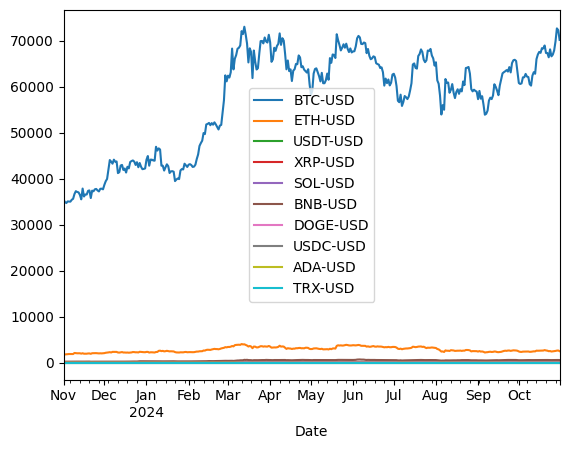

In [301]:
oneday_dataframe.plot()

In [302]:
oneday_dataframe = oneday_dataframe.reset_index(drop=True)

In [303]:
oneday_dataframe

,BTC-USD,ETH-USD,USDT-USD,XRP-USD,SOL-USD,BNB-USD,DOGE-USD,USDC-USD,ADA-USD,TRX-USD
0,35437.253906,1847.089722,1.000611,0.609538,41.461544,228.000107,0.068841,1.000233,0.307459,0.100256
1,34938.242188,1800.620972,1.000213,0.606439,40.207569,231.723022,0.067934,1.000120,0.323142,0.099295
2,34732.324219,1832.795166,1.000650,0.613002,39.519760,230.605972,0.068144,1.000249,0.329021,0.097313
3,35082.195312,1857.698608,1.000781,0.616184,42.346596,237.454605,0.069079,1.000175,0.328542,0.097778
4,35049.355469,1894.157715,1.000724,0.661147,41.238602,244.322479,0.071224,0.999997,0.342870,0.098220
...,...,...,...,...,...,...,...,...,...,...
361,67929.296875,2505.940674,0.998745,0.516381,176.549194,588.715820,0.144312,0.999957,0.339872,0.163871
362,69907.757812,2565.348145,0.999305,0.519227,178.104904,600.596069,0.161150,0.999855,0.343796,0.163997
363,72720.492188,2637.957520,0.999729,0.527916,179.360748,605.668274,0.175839,0.999934,0.355651,0.166231
364,72339.539062,2657.372559,0.999632,0.522974,174.924973,595.727844,0.168146,0.999832,0.355264,0.169259


In [304]:
gc_res = grangercausalitytests(oneday_dataframe[['XRP-USD','ETH-USD']], 1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.2116  , p=0.1378  , df_denom=362, df_num=1
ssr based chi2 test:   chi2=2.2300  , p=0.1354  , df=1
likelihood ratio test: chi2=2.2232  , p=0.1360  , df=1
parameter F test:         F=2.2116  , p=0.1378  , df_denom=362, df_num=1


In [305]:
most_related = None
p = 0

for _, coin1 in enumerate(coins):
    for __, coin2 in enumerate(coins):
        if coin1 == coin2:
            continue
        print(f"\nCoins : {coin1} , {coin2}")
        gc_res = grangercausalitytests(oneday_dataframe[[coin1, coin2]].pct_change().dropna(), 1)
        if gc_res[1][0]['ssr_ftest'][1] > p:
            p = gc_res[1][0]['ssr_ftest'][1]
            most_related = (coin1, coin2)


Coins : BTC-USD , ETH-USD

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0926  , p=0.7610  , df_denom=361, df_num=1
ssr based chi2 test:   chi2=0.0934  , p=0.7599  , df=1
likelihood ratio test: chi2=0.0934  , p=0.7599  , df=1
parameter F test:         F=0.0926  , p=0.7610  , df_denom=361, df_num=1

Coins : BTC-USD , USDT-USD

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1942  , p=0.6597  , df_denom=361, df_num=1
ssr based chi2 test:   chi2=0.1958  , p=0.6581  , df=1
likelihood ratio test: chi2=0.1958  , p=0.6582  , df=1
parameter F test:         F=0.1942  , p=0.6597  , df_denom=361, df_num=1

Coins : BTC-USD , XRP-USD

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0084  , p=0.9270  , df_denom=361, df_num=1
ssr based chi2 test:   chi2=0.0085  , p=0.9267  , df=1
likelihood ratio test: chi2=0.0085  , p=0.9267  , df=1
parameter F test:         F=0.0084  , p=0.9270  , df_denom=361, df_num=1

Coins : BTC

In [306]:
most_related

('TRX-USD', 'USDT-USD')

<Axes: >

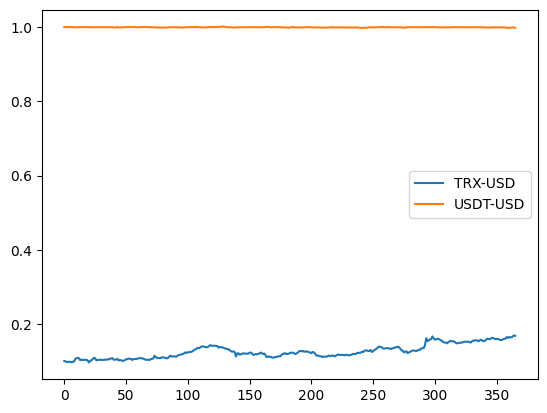

In [307]:
oneday_dataframe[[most_related[0], most_related[1]]].plot()